# 04 · Demonstração da gold — o star schema respondendo perguntas

Primeiro passeio pelo star schema do Painel 1: cada pergunta de negócio vira uma consulta SQL sobre fatos e dimensões conformadas (DuckDB), o resultado vira um gráfico (matplotlib). É demonstração, não análise: o objetivo é ver a gold funcionando, com os indicadores-base no grão certo e a história 2020-2026 aparecendo. Nenhum número é digitado.

**Como rodar:** com a gold construída (`uv run gold-staging`), kernel da `.venv` do projeto.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from logistica_fictitur.lake import conectar

conn = conectar()


def sql(consulta: str) -> pd.DataFrame:
    return conn.execute(consulta).df()


# paleta e anatomia: marcas finas, grade recessiva, texto em tinta de texto
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA_2, GRADE = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRADE, "axes.labelcolor": TINTA_2, "text.color": TINTA,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2, "axes.grid": True,
    "grid.color": GRADE, "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "figure.dpi": 110,
})


def figura(titulo: str, largura: float = 9, altura: float = 4):
    fig, ax = plt.subplots(figsize=(largura, altura))
    ax.set_title(titulo, loc="left", fontsize=12, color=TINTA, pad=12)
    ax.set_axisbelow(True)
    return fig, ax

## 1. A história em uma linha: OTIF por ano, pelo eixo da promessa

Pergunta: dos pedidos **prometidos** para cada ano, quantos chegaram no prazo? A `dim_data` entra no papel de data prometida ao cliente (`sk_data_prazo_cliente`); pedidos contam por `COUNT(DISTINCT ss)` porque o grão da fato é o item.

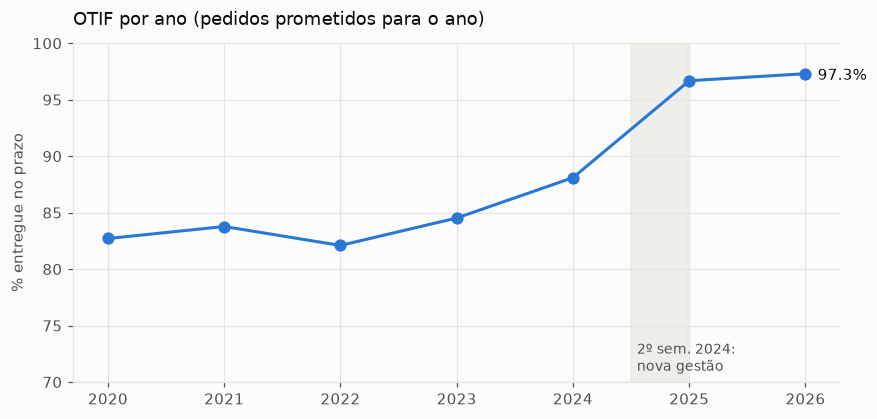

In [2]:
otif = sql("""
    SELECT d.ano,
           count(DISTINCT t.ss) FILTER (WHERE t.fl_no_prazo) * 1.0
           / count(DISTINCT t.ss) FILTER (WHERE t.fl_entregue AND NOT t.fl_data_entrega_invalida)
               AS otif
    FROM gold_fatos_ft_tracking t
    JOIN gold_dimensoes_dim_data d ON d.sk_data = t.sk_data_prazo_cliente
    GROUP BY 1 ORDER BY 1
""")
fig, ax = figura("OTIF por ano (pedidos prometidos para o ano)")
ax.plot(otif["ano"], otif["otif"] * 100, color=AZUL, linewidth=2, marker="o", markersize=7)
ax.set_ylim(70, 100)
ax.set_ylabel("% entregue no prazo")
ultimo = otif.iloc[-1]
ax.annotate(f"{ultimo.otif * 100:.1f}%", (ultimo.ano, ultimo.otif * 100),
            textcoords="offset points", xytext=(8, -4), color=TINTA)
ax.axvspan(2024.5, 2024.99, color=GRADE, alpha=0.6)
ax.text(2024.55, 71, "2º sem. 2024:\nnova gestão", color=TINTA_2, fontsize=9)
plt.show()

> **Nota Técnica 1**  
>**Observado:** a curva reproduz a narrativa do caso: patamar ruim e oscilante até 2023, salto no ano da virada e excelência a partir de 2025.
> - **Por que importa:** é a prova de que o star schema preserva a história depois de três camadas de transformação, e que o eixo escolhido (a promessa, não a entrega) é o que o contrato com o cliente cobra.
> - **Ação proposta:** este é o gráfico de abertura do primeiro dashboard; no painel, a linha ganha a faixa contratual por cliente vinda da `dim_cliente`.

## 2. Volume mensal de pedidos: sazonalidade e crescimento

Pergunta: como o volume evolui mês a mês? A mesma fato, agora pelo papel data de solicitação.

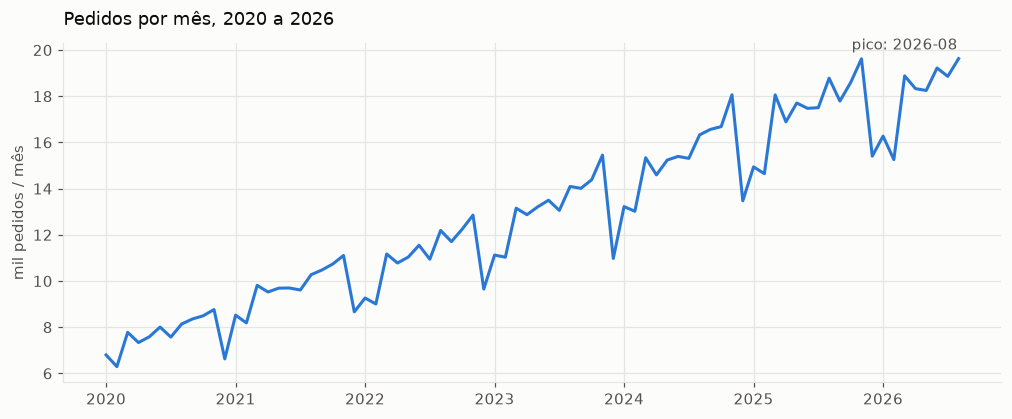

In [3]:
volume = sql("""
    SELECT d.ano_mes, count(DISTINCT t.ss) AS pedidos
    FROM gold_fatos_ft_tracking t
    JOIN gold_dimensoes_dim_data d ON d.sk_data = t.sk_data_solicitacao
    WHERE d.ano_mes < '2026-09'
    GROUP BY 1 ORDER BY 1
""")
fig, ax = figura("Pedidos por mês, 2020 a 2026", largura=11)
ax.plot(range(len(volume)), volume["pedidos"] / 1000, color=AZUL, linewidth=2)
marcas = [i for i, m in enumerate(volume["ano_mes"]) if m.endswith("-01")]
ax.set_xticks(marcas, [volume["ano_mes"][i][:4] for i in marcas])
ax.set_ylabel("mil pedidos / mês")
pico = volume.loc[volume["pedidos"].idxmax()]
ax.annotate(f"pico: {pico.ano_mes}", (volume.index[volume['ano_mes'] == pico.ano_mes][0],
            pico.pedidos / 1000), textcoords="offset points", xytext=(-70, 6), color=TINTA_2)
plt.show()

> **Nota Técnica 2**  
>**Observado:** tendência de crescimento ano após ano com o desenho sazonal repetido (vales no início do ano, picos no último trimestre).
> - **Por que importa:** volume e sazonalidade são o denominador de todo indicador de eficiência; sem eles, um OTIF de dezembro e um de fevereiro não se comparam.
> - **Ação proposta:** no dashboard, este gráfico vira o comparativo ano contra ano, calculado na apresentação (regra da matriz de barramento).

## 3. Quem sofria mais e quem ganhou mais: OTIF por porte, 2020 contra 2026

Pergunta: a virada alcançou os clientes pequenos, que em 2020 beiravam o churn? Duas dimensões conformadas em ação: `dim_cliente` (porte) e `dim_data` (prazo).

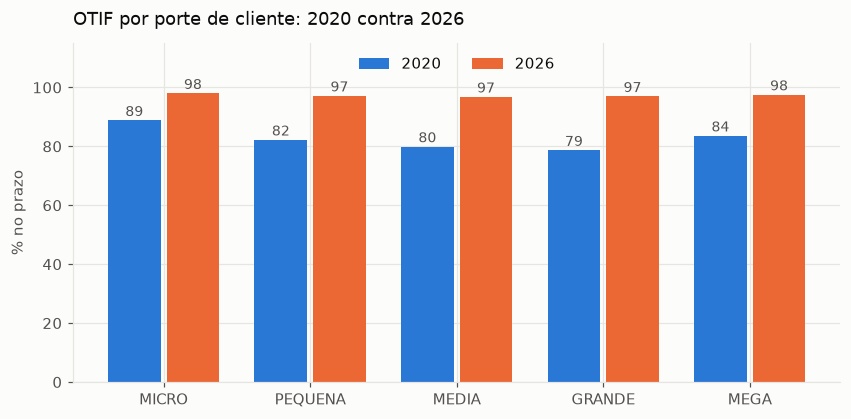

In [4]:
porte = sql("""
    SELECT c.porte, d.ano,
           count(DISTINCT t.ss) FILTER (WHERE t.fl_no_prazo) * 100.0
           / count(DISTINCT t.ss) FILTER (WHERE t.fl_entregue AND NOT t.fl_data_entrega_invalida)
               AS otif
    FROM gold_fatos_ft_tracking t
    JOIN gold_dimensoes_dim_cliente c ON c.sk_cliente = t.sk_cliente
    JOIN gold_dimensoes_dim_data d    ON d.sk_data = t.sk_data_prazo_cliente
    WHERE d.ano IN (2020, 2026)
    GROUP BY 1, 2
""").pivot(index="porte", columns="ano", values="otif")
porte = porte.reindex(["MICRO", "PEQUENA", "MEDIA", "GRANDE", "MEGA"])
fig, ax = figura("OTIF por porte de cliente: 2020 contra 2026")
pos = range(len(porte))
ax.bar([p - 0.2 for p in pos], porte[2020], width=0.36, color=AZUL, label="2020")
ax.bar([p + 0.2 for p in pos], porte[2026], width=0.36, color=LARANJA, label="2026")
ax.set_xticks(list(pos), porte.index)
ax.set_ylim(0, 115)
ax.set_ylabel("% no prazo")
for p, (v20, v26) in enumerate(zip(porte[2020], porte[2026], strict=True)):
    ax.text(p - 0.2, v20 + 1.5, f"{v20:.0f}", ha="center", color=TINTA_2, fontsize=9)
    ax.text(p + 0.2, v26 + 1.5, f"{v26:.0f}", ha="center", color=TINTA_2, fontsize=9)
ax.legend(frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.0))
plt.show()

> **Nota Técnica 3**  
>**Observado:** em 2020 o serviço era desigual por porte, numa faixa de cerca de dez pontos, e a surpresa está no meio da tabela: os portes **grande e médio** tinham o pior OTIF, puxados pelos clientes-problema, enquanto os micro estavam melhor; em 2026 a dispersão praticamente some, todos no patamar de excelência.
> - **Por que importa:** é a pergunta que o dono faz depois de ver a curva geral ("melhorou para todo mundo?"), respondida cruzando duas dimensões conformadas sem nenhum join extra na fato; e ela desmonta a intuição de que "cliente grande é sempre bem atendido".
> - **Ação proposta:** candidato a segundo gráfico do dashboard, com o porte como filtro lateral e o detalhe por cliente ao clicar.

## 4. Onde o frete fatura: receita por região comercial

Pergunta: qual a distribuição geográfica da receita de frete? `ft_frete` × `dim_geografia`, excluindo os fretes simbólicos (a flag herdada da silver) para não distorcer.

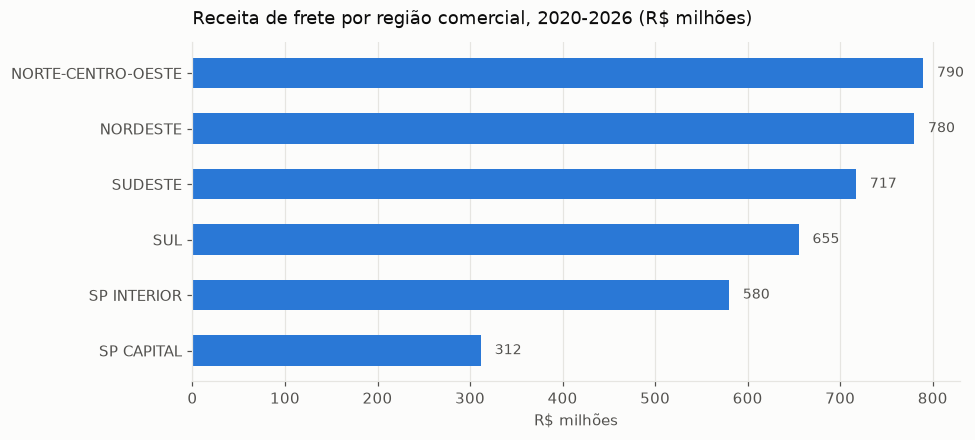

In [5]:
frete = sql("""
    SELECT g.regiao_comercial, sum(f.valor_frete_icms) / 1e6 AS receita_mm
    FROM gold_fatos_ft_frete f
    JOIN gold_dimensoes_dim_geografia g ON g.sk_geografia = f.sk_geografia
    WHERE NOT f.fl_frete_simbolico
    GROUP BY 1 ORDER BY 2
""")
fig, ax = figura("Receita de frete por região comercial, 2020-2026 (R$ milhões)")
ax.barh(frete["regiao_comercial"], frete["receita_mm"], color=AZUL, height=0.55)
for i, v in enumerate(frete["receita_mm"]):
    ax.text(v + 15, i, f"{v:,.0f}", va="center", color=TINTA_2, fontsize=9)
ax.set_xlabel("R$ milhões")
ax.grid(axis="y", visible=False)
plt.show()

> **Nota Técnica 4**  
>**Observado:** a receita de frete é liderada pelas regiões **distantes** (Norte/Centro-Oeste e Nordeste), e a capital paulista, onde a operação concentra volume, fica em último: receita de frete segue a **distância**, não o número de pedidos, porque o frete unitário cresce com a região.
> - **Por que importa:** é o clássico "volume não é receita"; um painel que mostrasse só pedidos por região contaria a história inversa. E o gráfico só é honesto porque a flag de frete simbólico deixou os centavos de retirada de fora.
> - **Ação proposta:** no painel, colocar este gráfico ao lado de "pedidos por região" e cruzar com a meta de R$/kg por região quando a `dim_meta_frete` existir.

## 5. O estoque ao longo do tempo: m³ ocupado nas fotos mensais

Pergunta: quanto espaço a operação ocupa, mês a mês? `ft_estoque_foto` somada por data de foto.

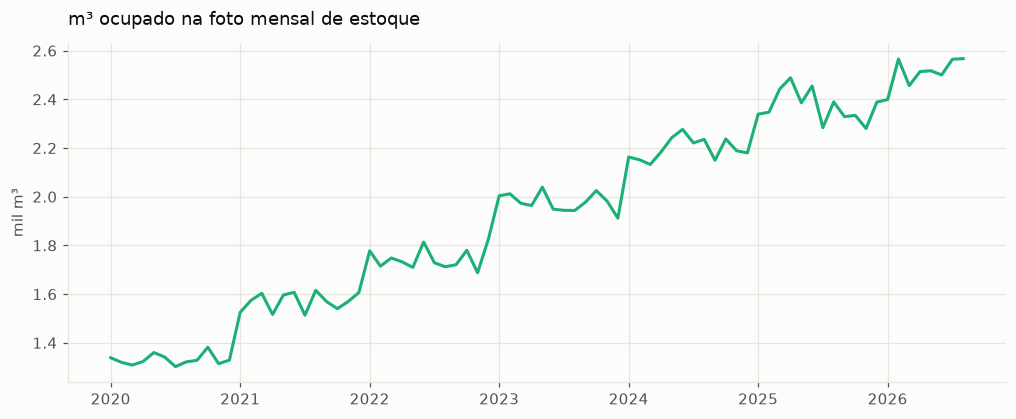

In [6]:
estoque = sql("""
    SELECT d.ano_mes, sum(e.m3_ocupado) AS m3
    FROM gold_fatos_ft_estoque_foto e
    JOIN gold_dimensoes_dim_data d ON d.sk_data = e.sk_data_foto
    WHERE d.ano_mes < '2026-09'
    GROUP BY 1 ORDER BY 1
""")
fig, ax = figura("m³ ocupado na foto mensal de estoque", largura=11)
ax.plot(range(len(estoque)), estoque["m3"] / 1000, color=AQUA, linewidth=2)
marcas = [i for i, m in enumerate(estoque["ano_mes"]) if m.endswith("-01")]
ax.set_xticks(marcas, [estoque["ano_mes"][i][:4] for i in marcas])
ax.set_ylabel("mil m³")
plt.show()

> **Nota Técnica 5**  
>**Observado:** o espaço ocupado cresce com o negócio, com variação mensal moderada em torno da tendência.
> - **Por que importa:** o m³ da foto é a base da cobrança de armazenagem e do custo do galpão; é a ponte entre o Painel 1 (materiais) e o Painel 2 (margens).
> - **Ação proposta:** na gold do Painel 2, a `ft_armazenagem_cobranca` lê exatamente estas fotos.

## 6. Fornecedores que não aparecem: no-show de agendamentos por ano

Pergunta: o no-show no recebimento melhorou com a nova gestão? `ft_agendamento` por ano de cadastro.

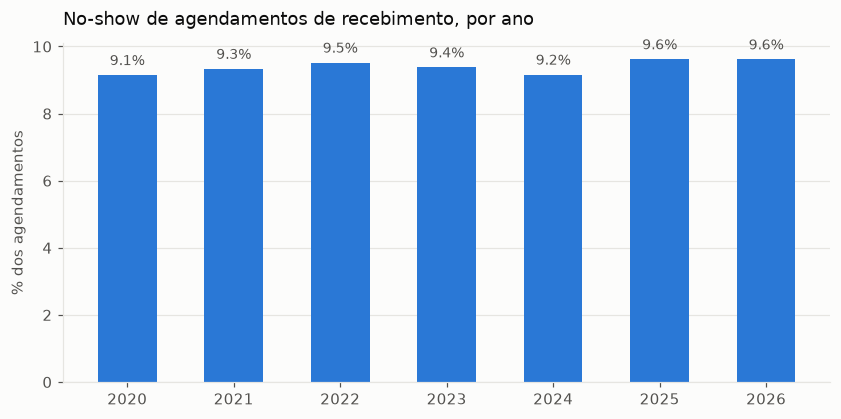

In [7]:
noshow = sql("""
    SELECT ano, count(*) FILTER (WHERE fl_no_show) * 100.0 / count(*) AS pct_no_show
    FROM gold_fatos_ft_agendamento
    GROUP BY 1 ORDER BY 1
""")
fig, ax = figura("No-show de agendamentos de recebimento, por ano")
ax.bar(noshow["ano"], noshow["pct_no_show"], color=AZUL, width=0.55)
for a, v in zip(noshow["ano"], noshow["pct_no_show"], strict=True):
    ax.text(a, v + 0.3, f"{v:.1f}%", ha="center", color=TINTA_2, fontsize=9)
ax.set_ylabel("% dos agendamentos")
ax.grid(axis="x", visible=False)
plt.show()

> **Nota Técnica 6 (fecho)**  
>**Observado:** o no-show se mantém num patamar estável ao longo do arco, sem a virada que o OTIF mostrou.
> - **Por que importa:** é um achado de demonstração honesto: nem tudo melhora junto, e um indicador plano ao lado de um em salto é exatamente o tipo de contraste que um painel deve deixar visível, não esconder. (No universo sintético, a taxa de no-show foi calibrada constante; o arco da história atuou sobre entregas e margens.)
> - **Ação proposta:** seguir para a régua de consistência da gold e para as fatos do Painel 2; o dashboard web abre com os gráficos 1, 3 e 4 desta demonstração.